In [255]:
import pandas as pd
import pickle
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from scipy.stats import chi2
import textwrap

In [256]:
DISEASE = input("Disease: ")
DISEASE_FOLDER = f"../output/{DISEASE}/"
RESULT_FOLDER = DISEASE_FOLDER + "leiden_results"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"

# Comm DGIDB genes count

In [257]:
def DGIDB_count(c,DGIDB_genes_ncbi):
    return set(c) & set(DGIDB_genes_ncbi)

In [258]:
with open(f"{RESULT_FOLDER}/result_communities_ncbi_selected.pkl", "rb") as f:
    communities_ncbi_selected = pickle.load(f)
with open(f"{RESULT_FOLDER}/result_communities_ncbi.pkl", "rb") as f:
    communities_ncbi = pickle.load(f)
with open(DGIDB_DIRECTORY + f"gene_to_index.json", "r") as file:
    DGIDB_gene_to_index = json.load(file)
DGIDB_genes = set(DGIDB_gene_to_index.keys())

FileNotFoundError: [Errno 2] No such file or directory: '../output//leiden_results/result_communities_ncbi_selected.pkl'

In [ ]:
comm_dgidb_gene_count = {}
for i in range(len(communities_ncbi_selected)):
    dgidb_genes_set = DGIDB_count(communities_ncbi[i],DGIDB_genes)
    print(i,len(dgidb_genes_set), dgidb_genes_set)
    print(len(communities_ncbi[i]))
    comm_dgidb_gene_count[i] = len(dgidb_genes_set)
    
with open(f"../output/{DISEASE}/comm_dgidb_gene_count.json","w") as f:
    json.dump(comm_dgidb_gene_count,f)    

0 3 {'627', '2936', '3567'}
3445
1 3 {'100422871', '6295', '100422959'}
2869
2 1 {'3107'}
2868
3 0 set()
2784
4 29 {'7916', '1831', '3484', '28234', '462', '4494', '10866', '3559', '4214', '170954', '6361', '2952', '4439', '79969', '1103', '55816', '4292', '5729', '332', '552859', '7069', '3726', '2114', '1317', '5858', '3363', '494514', '942', '4689'}
2705
5 0 set()
2233
6 7 {'219983', '29113', '574406', '200765', '170679', '168400', '135656'}
2231
7 15 {'6573', '3718', '83716', '7038', '3880', '653509', '5104', '540', '70', '2348', '2342', '9607', '538', '4880', '10993'}
2159
8 0 set()
472
9 0 set()
51


# important terms processing

In [ ]:
with open(f"{RESULT_FOLDER}/result_communities_selected.pkl", "rb") as f:
    communities_selected = pickle.load(f)

In [ ]:
important_terms = pd.read_csv(DISEASE_FOLDER + "important_terms.csv")

In [ ]:
important_terms = important_terms.sort_values(
    by=["Community Index", "Adjusted P-value"],
    ascending=[True, True]
).reset_index(drop=True)

In [ ]:
important_terms

,Community Index,Community Size,Term,Overlap,Adjusted P-value,Category,Gene_set,P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Overlap (value)
0,0,1460,Intracellular Membrane-Bounded Organelle (GO:0...,592/5175,1.078402e-34,['cellular anatomical structure'],GO_Cellular_Component_2023,2.898930e-37,0.0,0.0,2.077037,174.743825,TESK1;SMC5;ADARB1;ABCA12;ZMIZ1;ALKBH1;ANKFY1;H...,0.114396
1,0,1460,"Signaling By Rho GTPases, Miro GTPases And RHO...",150/660,2.321737e-34,['Signal Transduction'],Reactome_2022,1.928353e-37,0.0,0.0,4.048047,342.217748,CYFIP1;ANKLE2;NUP107;RTKN;STMN2;CCP110;FNBP1L;...,0.227273
2,0,1460,Signaling By Rho GTPases R-HSA-194315,147/644,3.841647e-34,['Signal Transduction'],Reactome_2022,6.381473e-37,0.0,0.0,4.064480,338.742889,CYFIP1;ANKLE2;NUP107;RTKN;STMN2;CCP110;FNBP1L;...,0.228261
3,0,1460,Nucleus (GO:0005634),516/4487,1.945748e-29,['cellular anatomical structure'],GO_Cellular_Component_2023,1.046101e-31,0.0,0.0,2.005430,143.057503,TESK1;SMC5;ADARB1;ZMIZ1;ALKBH1;HOXA1;IER5;HOXA...,0.114999
4,0,1460,RHO GTPase Cycle R-HSA-9012999,109/441,4.571193e-28,['Signal Transduction'],Reactome_2022,1.139002e-30,0.0,0.0,4.424817,305.079628,CYFIP1;ANKLE2;RTKN;STMN2;CCP110;FNBP1L;PREX2;D...,0.247166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
816,9,16,Positive Regulation Of Telomere Capping (GO:19...,2/16,5.784337e-04,['biological regulation'],GO_Biological_Process_2023,7.153149e-05,0.0,0.0,203.775510,1945.113204,MAPK1;MAPK3,0.125000
817,9,16,Regulation Of Golgi Organization (GO:1903358),2/16,5.784337e-04,['biological regulation'],GO_Biological_Process_2023,7.153149e-05,0.0,0.0,203.775510,1945.113204,MAPK1;MAPK3,0.125000
818,9,16,Positive Regulation Of Cardiac Muscle Hypertro...,2/17,6.394638e-04,['biological regulation'],GO_Biological_Process_2023,8.103129e-05,0.0,0.0,190.180952,1791.632979,ROCK1;PRKCA,0.117647
819,9,16,Positive Regulation Of Focal Adhesion Assembly...,2/18,7.105016e-04,['biological regulation'],GO_Biological_Process_2023,9.111776e-05,0.0,0.0,178.285714,1658.655789,ROCK1;RAC1,0.111111


# Community Category df

In [ ]:
df = important_terms

# ---------------------------------------------------
# 1. Parse Category column (stringified list) -> list
# ---------------------------------------------------
df["Category"] = df["Category"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# ---------------------------------------------------
# 2. Explode: one category per row
# ---------------------------------------------------
df_exp = df.explode("Category").reset_index(drop=True)

# ---------------------------------------------------
# 3. Parse Overlap "a/b" into numerator and denominator
# ---------------------------------------------------
def parse_overlap(s):
    try:
        a, b = s.split("/")
        return int(a), int(b)
    except Exception:
        return 0, 0

overlap_nums = []
overlap_dens = []

for s in df_exp["Overlap"]:
    a, b = parse_overlap(s)
    overlap_nums.append(a)
    overlap_dens.append(b)

df_exp["Overlap_num"] = overlap_nums
df_exp["Overlap_den"] = overlap_dens

# ---------------------------------------------------
# 4. Total number of terms per community
# ---------------------------------------------------
total_terms = (
    df_exp.groupby("Community Index")["Term"]
          .nunique()
)

# ---------------------------------------------------
# 5. Aggregate per (Community Index, Category)
#    - count = # of distinct terms
#    - Gross Overlap = (sum a_i) / (sum b_i)
# ---------------------------------------------------
# ---------------------------------------------------
# 5. Aggregate per (Community Index, Category)
#    - count = # of distinct terms
#    - Gross Overlap = (sum a_i) / (sum b_i)
#    - fisher_p = Fisher-combined p-value over terms in that category
# ---------------------------------------------------
def fisher_method(pvals):
    p = pd.Series(pvals).dropna().astype(float)
    if len(p) == 0:
        return np.nan

    # avoid log(0)
    p = p.clip(lower=1e-300)

    stat = -2.0 * np.sum(np.log(p))
    df = 2 * len(p)
    return float(chi2.sf(stat, df))

agg = (
    df_exp.groupby(["Community Index", "Category"])
    .agg(
        count=("Term", "nunique"),
        sum_a=("Overlap_num", "sum"),
        sum_b=("Overlap_den", "sum"),
        fisher_p=("Adjusted P-value", fisher_method),  # <-- change column name if needed
    )
    .reset_index()
)

agg["Gross Overlap"] = agg["sum_a"] / agg["sum_b"]

# ---------------------------------------------------
# 6. Add total_terms_in_comm and frac_of_comm
# ---------------------------------------------------
agg["total_terms_in_comm"] = agg["Community Index"].map(total_terms)
agg["frac_of_comm"] = agg["count"] / agg["total_terms_in_comm"]

# ---------------------------------------------------
# 7. Final output df
# ---------------------------------------------------
community_categories = agg[[
    "Community Index",
    "Category",
    "count",
    "Gross Overlap",
    "fisher_p",
    "total_terms_in_comm",
    "frac_of_comm",
]]


community_categories = community_categories.sort_values(
    by=["Community Index", "count"],
    ascending=[True, False]
).reset_index(drop=True)

community_categories


,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm
0,0,cellular process,144,0.240435,0.000000e+00,553,0.260398
1,0,biological regulation,133,0.183272,0.000000e+00,553,0.240506
2,0,cellular anatomical structure,54,0.145374,3.972119e-300,553,0.097649
3,0,localization,44,0.249943,5.620753e-221,553,0.079566
4,0,binding,26,0.177821,1.078126e-160,553,0.047016
...,...,...,...,...,...,...,...
92,9,Metabolism of RNA,1,0.200000,1.319481e-04,85,0.011765
93,9,Neuronal System,1,0.285714,6.747709e-05,85,0.011765
94,9,Signal transduction,1,0.135593,7.244149e-16,85,0.011765
95,9,binding,1,0.222222,1.999161e-04,85,0.011765


In [ ]:
community_categories["fisher_score"] = -np.log10(
    community_categories["fisher_p"].clip(lower=1e-300)
)

mn = community_categories["fisher_score"].min()
mx = community_categories["fisher_score"].max()

community_categories["fisher_norm"] = (community_categories["fisher_score"] - mn) / (mx - mn)

def safe_z(x):
    mu = x.mean()
    sd = x.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return pd.Series(0.0, index=x.index)   # or return x*0
    return (x - mu) / sd

community_categories["fisher_z"] = (
    community_categories
    .groupby("Community Index")["fisher_score"]
    .transform(safe_z)
)




In [ ]:
community_categories

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_norm,fisher_z
0,0,cellular process,144,0.240435,0.000000e+00,553,0.260398,300.000000,1.000000,2.415356
1,0,biological regulation,133,0.183272,0.000000e+00,553,0.240506,300.000000,1.000000,2.415356
2,0,cellular anatomical structure,54,0.145374,3.972119e-300,553,0.097649,299.400978,0.997983,2.408881
3,0,localization,44,0.249943,5.620753e-221,553,0.079566,220.250206,0.731474,1.553252
4,0,binding,26,0.177821,1.078126e-160,553,0.047016,159.967331,0.528494,0.901588
...,...,...,...,...,...,...,...,...,...,...
92,9,Metabolism of RNA,1,0.200000,1.319481e-04,85,0.011765,3.879597,0.002930,-0.638610
93,9,Neuronal System,1,0.285714,6.747709e-05,85,0.011765,4.170844,0.003910,-0.624466
94,9,Signal transduction,1,0.135593,7.244149e-16,85,0.011765,15.140013,0.040845,-0.091760
95,9,binding,1,0.222222,1.999161e-04,85,0.011765,3.699152,0.002322,-0.647373


## filtering top 5 categories

In [ ]:
# community_categories_filtered = (
#     community_categories.sort_values(["Community Index", "count"], ascending=[True, False])
#           .groupby("Community Index")
#           .head(5)
#           .reset_index(drop=True)
# )

In [ ]:
# community_categories_filtered

In [ ]:
# from reportlab.lib.pagesizes import letter, landscape
# from reportlab.platypus import SimpleDocTemplate, Table, TableStyle
# from reportlab.lib import colors

# def df_to_pdf(df, filename="output.pdf"):
#     pdf = SimpleDocTemplate(
#         filename,
#         pagesize=landscape(letter)
#     )

#     # Convert DF to 2D list
#     data = [df.columns.tolist()] + df.values.tolist()

#     # Create table
#     table = Table(data)

#     # Styling
#     style = TableStyle([
#         ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
#         ("TEXTCOLOR", (0,0), (-1,0), colors.black),
#         ("ALIGN", (0,0), (-1,-1), "CENTER"),
#         ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
#         ("FONTSIZE", (0,0), (-1,-1), 8),
#         ("BOTTOMPADDING", (0,0), (-1,0), 8),
#         ("GRID", (0,0), (-1,-1), 0.25, colors.black),
#     ])
#     table.setStyle(style)

#     elements = [table]
#     pdf.build(elements)
#     print(f"PDF saved to {filename}")


## output to pdf

In [ ]:
# community_categories_filtered

In [ ]:
# df_to_pdf(community_categories_filtered, f"../../Graphs/{DISEASE}/community_categories_filtered.pdf")

# Community Count Dict

In [ ]:
category_count_by_comm = {}

for _, row in community_categories.iterrows():
    comm = row["Community Index"]
    cat = row["Category"]
    count = row["count"]
    gross = row["Gross Overlap"]

    if comm not in category_count_by_comm:
        category_count_by_comm[comm] = {}

    # insertion happens in sorted order because community_categories is sorted
    category_count_by_comm[comm][cat] = (count, gross)


In [ ]:
for i in range(len(communities_selected)):
    if i not in category_count_by_comm.keys():
        category_count_by_comm[i] = {}

In [ ]:
category_count_by_comm

{0: {'cellular process': (144, 0.2404345202172601),
  'biological regulation': (133, 0.18327183271832717),
  'cellular anatomical structure': (54, 0.14537444933920704),
  'localization': (44, 0.24994272623138603),
  'binding': (26, 0.17782079646017698),
  'Signal Transduction': (21, 0.1943086592178771),
  'Cell Cycle': (18, 0.2034419176398279),
  'catalytic activity': (17, 0.19948102497567305),
  'Disease': (15, 0.20656226696495153),
  'protein-containing complex': (15, 0.4225352112676056),
  'Metabolism of proteins': (14, 0.15460013366005793),
  'Metabolism of RNA': (13, 0.24287343215507412),
  'response to stimulus': (10, 0.18222222222222223),
  'Immune System': (8, 0.13697299397707402),
  'Vesicle-mediated transport': (8, 0.18116740088105726),
  'Cellular responses to stimuli': (7, 0.14669652855543114),
  'Organelle biogenesis and maintenance': (5, 0.24088748019017434),
  'Folding, sorting and degradation': (4, 0.2624113475177305),
  'Metabolism': (4, 0.25660377358490566),
  'Gene e

In [ ]:
with open(f"{DISEASE_FOLDER}/category_count_by_comm.pkl", "wb") as f:
    pickle.dump(category_count_by_comm, f)

# Heatmap with filtered categories

In [ ]:
counts = important_terms["Community Index"].value_counts()
top_idx = counts.idxmax()

In [ ]:
comm_dgidb_gene_count_new = {k: v for k, v in comm_dgidb_gene_count.items() if k != top_idx}

In [ ]:
comm_dgidb_gene_count_new

{1: 3, 2: 1, 3: 0, 4: 29, 5: 0, 6: 7, 7: 15, 8: 0, 9: 0}

In [ ]:
idx = list(sorted([u for u,v in comm_dgidb_gene_count_new.items() if v > 0 and u in community_categories["Community Index"].unique()], key = comm_dgidb_gene_count_new.get, reverse=True))

In [ ]:
idx

[4, 7, 2]

In [ ]:
with open(f"{DISEASE_FOLDER}/important_comm_idx.pkl", "wb") as f:
    pickle.dump(idx, f)

In [ ]:
community_categories_filtered = community_categories[community_categories["Community Index"].isin(idx)]

In [ ]:
community_categories_filtered

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_norm,fisher_z
30,2,cellular process,32,0.205787,3.873954e-101,105,0.304762,100.411846,0.327964,2.389482
31,2,localization,22,0.196653,7.684943e-79,105,0.209524,78.114359,0.252886,1.677560
32,2,cellular anatomical structure,18,0.151750,7.157459e-98,105,0.171429,97.145241,0.316965,2.285184
33,2,Vesicle-mediated transport,7,0.172772,1.051986e-43,105,0.066667,42.977990,0.134578,0.555714
34,2,Metabolism,6,0.194745,3.013974e-19,105,0.057143,18.520860,0.052228,-0.225161
35,2,catalytic activity,5,0.315789,1.507215e-20,105,0.047619,19.821825,0.056609,-0.183624
36,2,Glycan biosynthesis and metabolism,4,0.345912,1.974441e-17,105,0.038095,16.704556,0.046113,-0.283153
37,2,Metabolism of proteins,4,0.128440,1.268274e-20,105,0.038095,19.896787,0.056861,-0.181230
38,2,Lipid metabolism,3,0.269231,6.327193e-15,105,0.028571,14.198789,0.037675,-0.363158
39,2,Metabolism of RNA,3,0.223256,9.446121e-09,105,0.028571,8.024747,0.016887,-0.560285


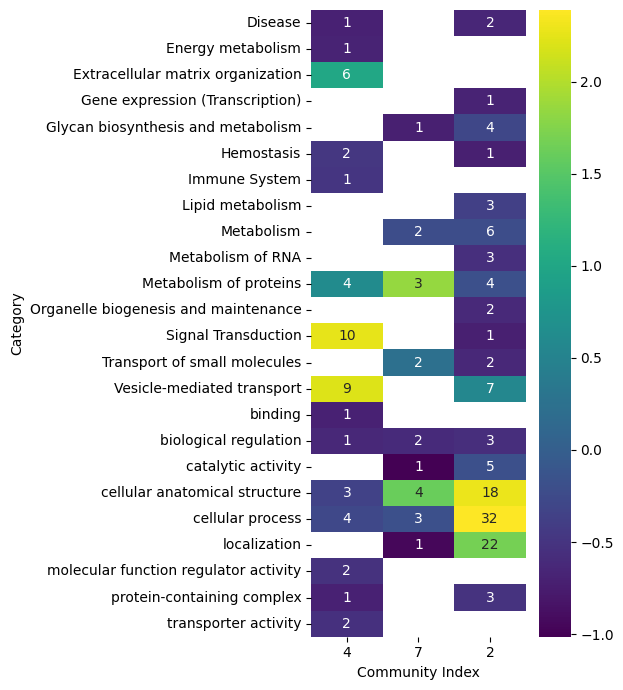

In [ ]:
heat_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="fisher_z"
).reindex(columns = idx)

label_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="count"
).reindex(columns = idx)
plt.figure(figsize=(6, 7))
ax = sns.heatmap(
    heat_df,
    cmap="viridis",
    annot=label_df,   # <-- use count for labels
    fmt=".0f",        # integer labels
    cbar=True
)

# ---- WRAP Y-AXIS LABELS ----
MAX_CHARS = 50  # tweak this
wrapped = ["\n".join(textwrap.wrap(str(s), width=MAX_CHARS)) for s in heat_df.index]
ax.set_yticklabels(wrapped, rotation=0)  # keep horizontal

plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/category_gross_overlap_heatmap.png", bbox_inches="tight")
plt.show()
